<a href="https://colab.research.google.com/github/uniquegalaxycoder/Project/blob/main/medical_insurance_data_%7C_insurance_charges_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Insurance ( Charge Prediction )**

## **Problem Statement:**
MedicaInsure is a medical insurance provider. Leveraging customer information is of paramount importance for most businesses. In the case of an insurance company, analysis of customer attributes like age, sex, smoking habits, etc. can be crucial in making decisions regarding the premium amount to be charged.



## **Data Disctionary**


**age:** age of the policyholder

**sex:** gender of the policyholder

**bmi:** Body Mass Index of the policyholder

**children**: number of children of the policyholder

**smoker:** whether the policyholder is a smoker or not

**region**: region where the policyholder belongs to

**charges:** premium charged to the policyholder

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

pd.options.display.float_format = '{:.2}'.format

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# Read data

try :
  data = pd.read_csv('/content/drive/My Drive/Python 2026/practice csv files/insurance.csv')
  print("Data Loaded successfully 🚀" )
except Exception as a :
  print("DataLoadError!", a)

Data Loaded successfully 🚀


In [4]:
# making a copy of original data

df = data.copy()
df2 = data.copy()

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,2.8e+01,0,yes,southwest,1.7e+04
1,18,male,3.4e+01,1,no,southeast,1.7e+03
2,28,male,3.3e+01,3,no,southeast,4.4e+03
3,33,male,2.3e+01,0,no,northwest,2.2e+04
4,32,male,2.9e+01,0,no,northwest,3.9e+03


In [6]:
list(df.columns)

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

In [7]:
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 1338
Columns : 7


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


- There is a 7 columns out of that 4 column were numerical & 3 column were categorical.
- all are NonNull columns.

In [9]:
pd.options.display.float_format = '{:.2f}'.format

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.00,39.21,14.05,18.00,27.00,39.00,51.00,64.00
bmi,1338.00,30.66,6.10,15.96,26.30,30.40,34.69,53.13
children,1338.00,1.09,1.21,0.00,0.00,1.00,2.00,5.00
charges,1338.00,13270.42,12110.01,1121.87,4740.29,9382.03,16639.91,63770.43


- There are 1338 total rows.
- AGE, average age of customer is 39.21 year old. minimum age of customer started from 18 and maximum age of customer is 64 year old. Std. in age is 14.05 the coefficent of variance is around 0.35 which is moderate variance in age.
- BMI, average bmi around 31. minimum bmi is around 15.96 & maximum bmi is around 53.13. variance is 0.19 which is indicating the low variance is bmi data.
- Children, on an average customer having 1 child, some of customer were 0 child & sme of customer has more than 1 child. customer child ranges betwen 0-5., 5 is a higher side.
- Charges, on an average insurance chargeing around 13270.42 but this is on some varibales/conditions. minimum charge is around 1121 & maximum side charges around 63770.43.

In [11]:
df.describe(include=['object', 'category']).T

,count,unique,top,freq
sex,1338,2,male,676
smoker,1338,2,no,1064
region,1338,4,southeast,364


## **Q1. What does the distribution of bmi look like after applying the log transformation on it?**

**Note: Create a new transformed column. Do not replace the existing column.**

In [12]:
df['bmi_after_log'] = np.log(df['bmi'])

In [146]:

df.head(2)

,age,sex,bmi,children,smoker,region,charges,bmi_after_log
0,19,female,2.8e+01,0,yes,southwest,1.7e+04,3.3
1,18,male,3.4e+01,1,no,southeast,1.7e+03,3.5


<Axes: xlabel='bmi_after_log', ylabel='Count'>

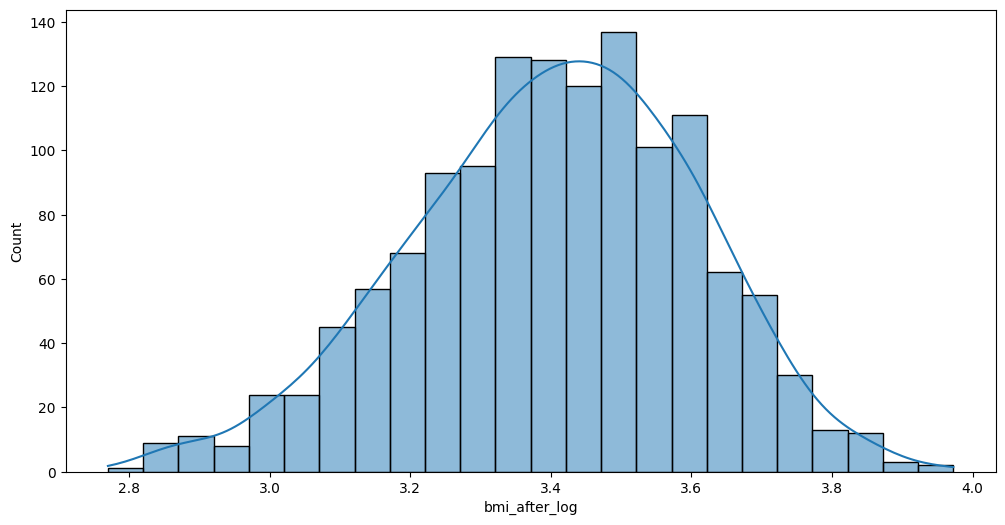

In [147]:
plt.figure(figsize= (12, 6))

sns.histplot(data=df, x = 'bmi_after_log', kde = True)



In [148]:
pd.options.display.float_format = '{:.2f}'.format

In [149]:
df.groupby('region')['charges'].median()

,charges
region,
northeast,10057.65
northwest,8965.80
southeast,9294.13
southwest,8798.59


In [150]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_after_log
0,19,female,27.90,0,yes,southwest,16884.92,3.33
1,18,male,33.77,1,no,southeast,1725.55,3.52
2,28,male,33.00,3,no,southeast,4449.46,3.50
3,33,male,22.70,0,no,northwest,21984.47,3.12
4,32,male,28.88,0,no,northwest,3866.86,3.36


In [151]:
df.select_dtypes(include = ['number']).corr()

,age,bmi,children,charges,bmi_after_log
age,1.00,0.11,0.04,0.30,0.12
bmi,0.11,1.00,0.01,0.20,0.99
children,0.04,0.01,1.00,0.07,0.01
charges,0.30,0.20,0.07,1.00,0.20
bmi_after_log,0.12,0.99,0.01,0.20,1.00


In [152]:
X = df.drop('charges', axis = 1)
y = df['charges']

In [159]:
X = pd.get_dummies(
    X,
    columns = X.select_dtypes(include = ['object', 'category']).columns.tolist(),
    drop_first = True
).astype('float')

In [161]:
X_tain, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.30,
    random_state=1
)

In [162]:
model = LinearRegression()

In [163]:
model.fit(X_train, y_train)

LinearRegression()

In [164]:
model.coef_

array([-2.89305055e-13, -6.67133015e-13, -4.70093081e-13,  1.00000000e+00,
        8.81600925e-13,  5.80791265e-13,  2.55445812e-13, -1.93738559e-12,
        2.81976951e-13])

In [165]:
model.intercept_

np.float64(2.1827872842550278e-11)

In [169]:
def Model_performance_regression(model, prdictors, target) :
    """
    Model to compute different metrics to check regression model performance

    model = Regression Model
    predictors = Independent variable
    target = dependent variable
    """

    pred = model.predict(prdictors)

    mape = mean_absolute_percentage_error(target, pred)
    mae = mean_absolute_error(target, pred)
    mse = mean_squared_error(target, pred)
    rmse = np.sqrt(mean_squared_error(target, pred))
    r2 = r2_score(target, pred)
    # adj_r2 = adj_r2_score(prdictors,target, pred)

    summary = pd.DataFrame({
        "MAPE" :  mape,
        "MAE" : mae,
        "MSE" : mse,
        "RMSE" : rmse,
        "R2 Score" : r2
        # "adj_r2" : adj_r2
    }, index = [0])

    return summary

In [170]:
Model_performance_regression(model, X_train, y_train)

,MAPE,MAE,MSE,RMSE,R2 Score
0,0.00,0.00,0.00,0.00,1.00


# **New Work**

# **Exploratory Analysis**

## **Univariate Analysis**

Plotting a subplot for all individula varibales

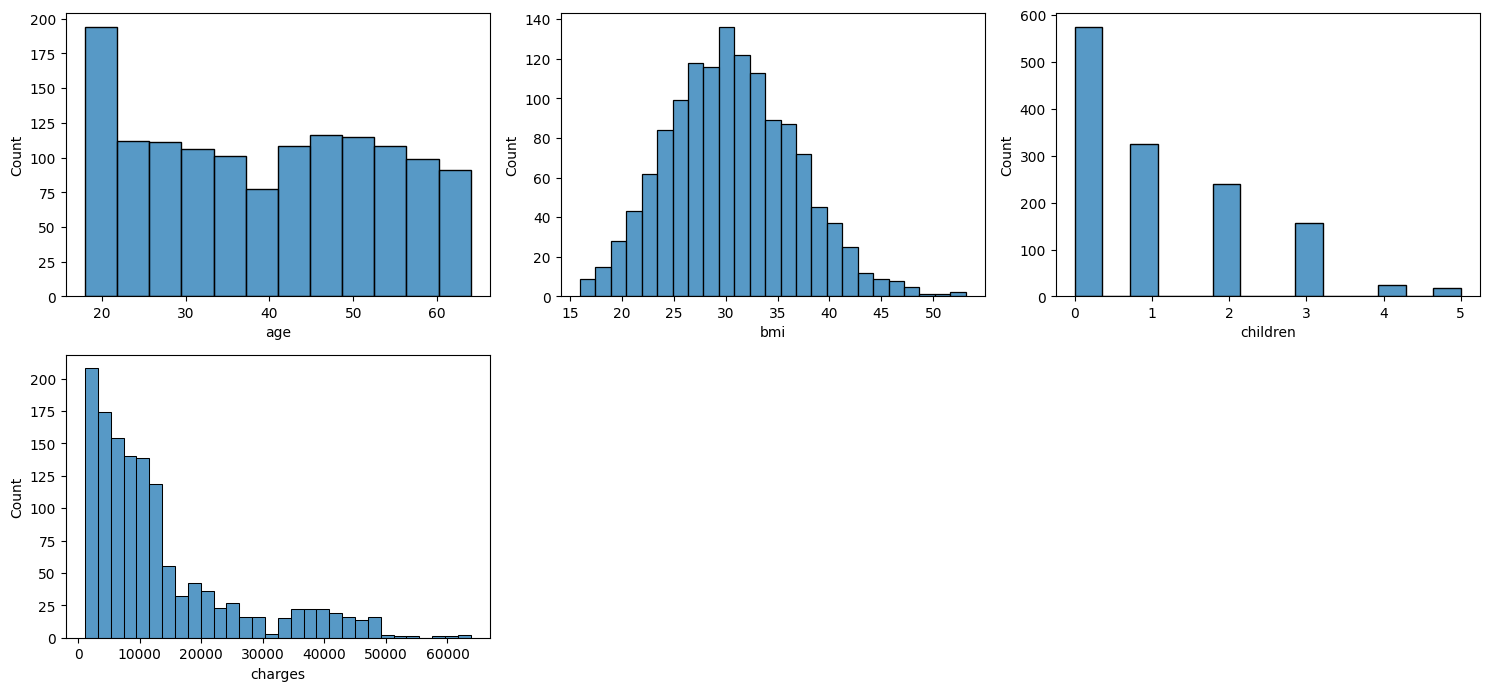

In [13]:
plt.figure(figsize = (15, 10))

features = df2.select_dtypes(include = ['number']).columns.tolist()

for i, feature in enumerate(features) :
  plt.subplot(3, 3, i+1)
  sns.histplot(data=df, x = feature)

plt.tight_layout()
plt.show()

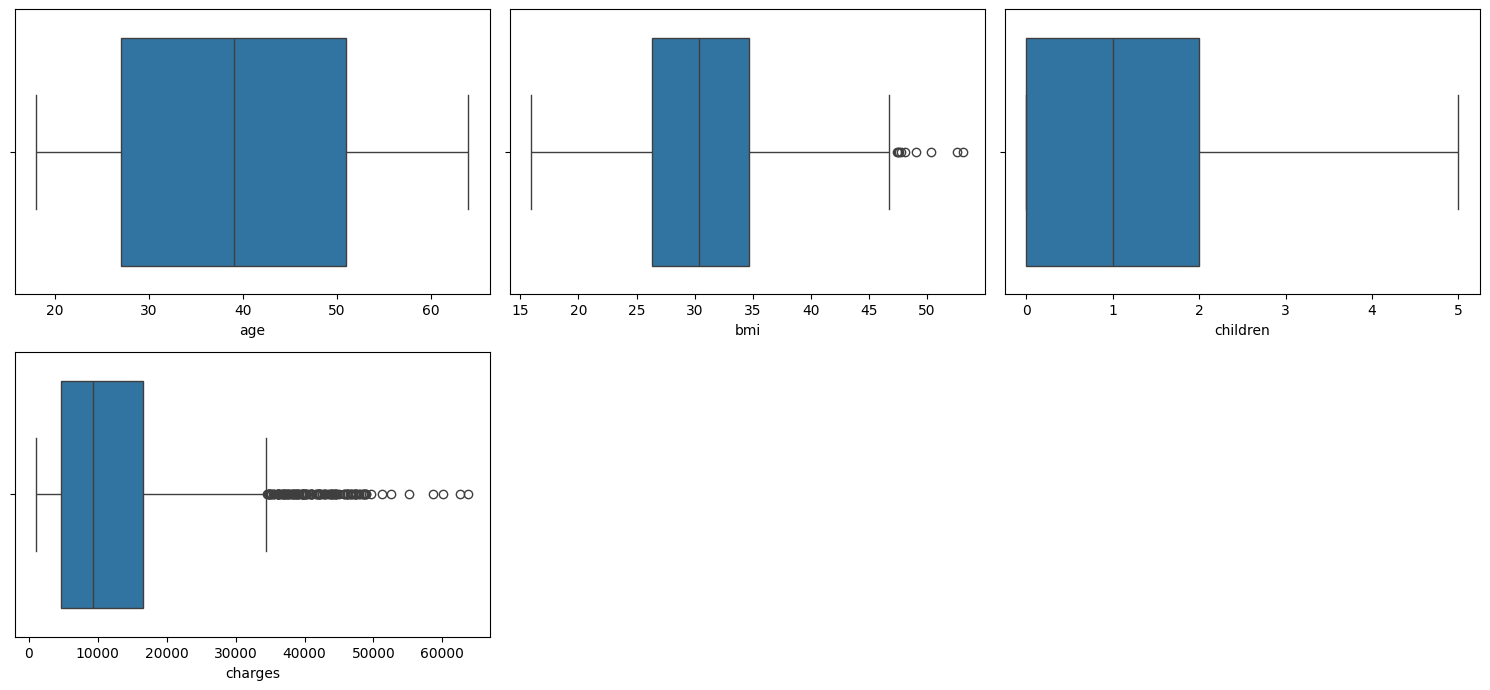

In [14]:
plt.figure(figsize = (15, 10))

features_1 = df2.select_dtypes(include = ['number']).columns.tolist()

for i, feature_1 in enumerate(features_1):
  plt.subplot(3, 3, i+1)
  sns.boxplot(data=df, x = feature_1)
plt.tight_layout()
plt.show()

**Observation's :**

- Age, age is not a normally distributed, it's slightly right side skewed. 50% of customers are < 39 year old. 25% of customers are less than 26 year old. if we see, in histplot more no. of customer lies in 18-20 year old.
- BMI, data is right side skewed, and also outliers are present. 50% of the customers are bmi is less than or equal to 30. which is good indicator.
- Children, data is highly right side skewed. 50% of the customers has no child.
- Charges, data is highly right side skewed. as per the data 25% of the customers paying insurance charge 5000. 50% of customers has paying <= 10000. but more outliers are present in left side.



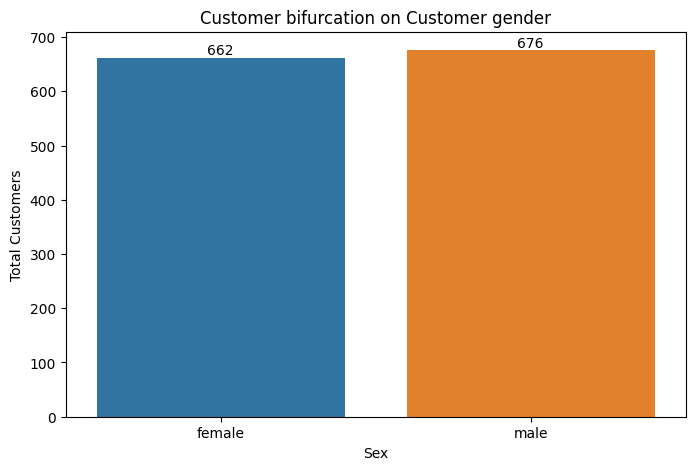

In [15]:
plt.figure(figsize = (8, 5))
plt.title("Customer bifurcation on Customer gender")
plot_1 = sns.countplot(data=df2, x = 'sex', hue = 'sex')
plt.xlabel('Sex')
plt.ylabel('Total Customers')

for value in plot_1.containers:
  plot_1.bar_label(value)
plt.show()

There are 662 customers has female & 676 customers a re male.

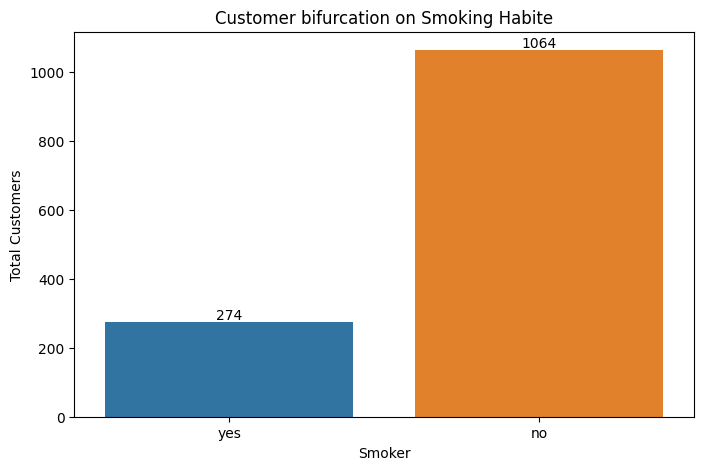

In [16]:
plt.figure(figsize = (8,5))
plt.title("Customer bifurcation on Smoking Habite")
plot_2 = sns.countplot(data=df2, x = 'smoker', hue = 'smoker')
plt.xlabel('Smoker')
plt.ylabel('Total Customers')

for value in plot_2.containers:
  plot_2.bar_label(value)

plt.show()

There are 274 customers were falldown in smkoing category out of 1338 customers. it almost 20.47% customers are smoking. 1064 customer are falldown in non-smoker category which is indicating good.


# **Bivariate Analysis**

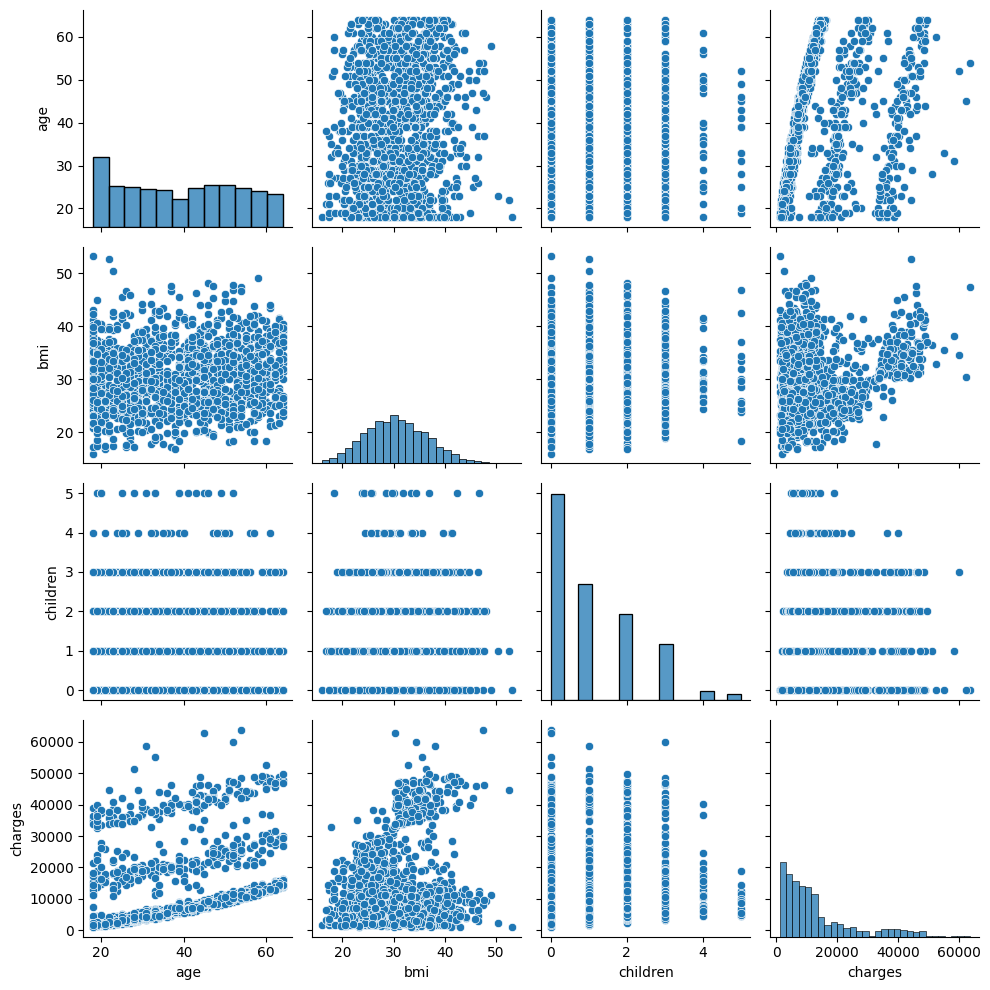

In [17]:
sns.pairplot(df2)
plt.tight_layout()
plt.show()

<Axes: >

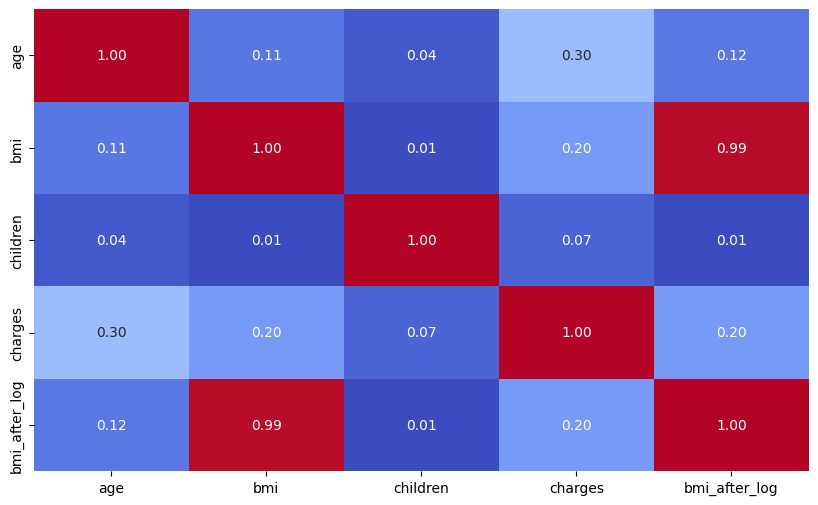

In [18]:
plt.figure(figsize = (10, 6))
sns.heatmap(data= df.select_dtypes(include = ['number']).corr(), annot = True, cbar = False, fmt = '0.2f', cmap = 'coolwarm')

- Here Charges Vs. age is postive correalted with each other but data points very scattered, like data points are widly spreded.
- Charges Vs. bmi is postive correlated but data points are scattered.
- in Children & Charges have no correlated with each others. there is no relation between them.

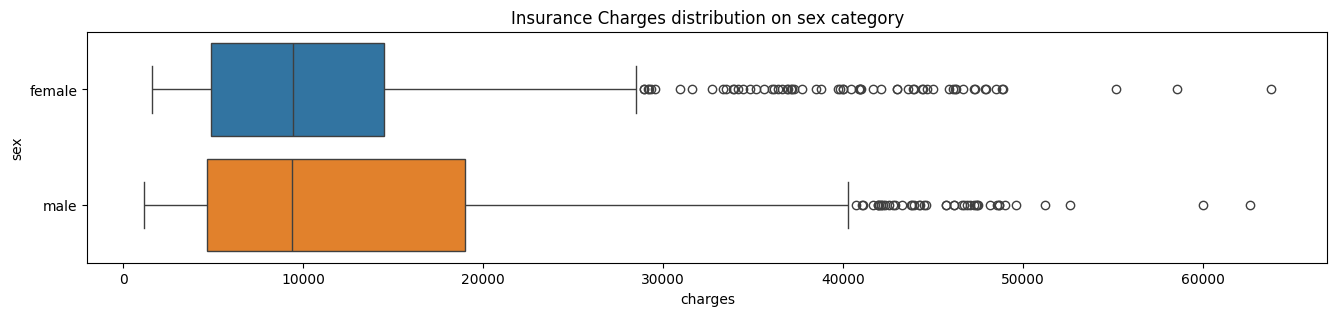

In [19]:
plt.figure(figsize=(16,3))
plt.title("Insurance Charges distribution on sex category")
sns.boxplot(data=df2, x='charges', y='sex', hue = 'sex')
plt.show()

In [20]:
df2['encoded_sex'] = df2['sex'].apply(lambda e : 1 if e == 'male' else 0)

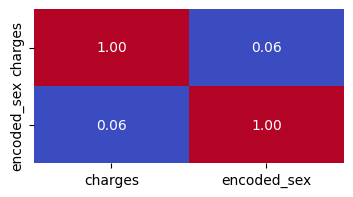

In [21]:
plt.figure(figsize = (4, 2))
sns.heatmap(data = df2[['charges', 'encoded_sex']].corr(), annot = True, cbar = False, fmt = '0.2f', cmap = 'coolwarm')
plt.show()

- Here we can see in Female & male sex category, 50% of the both the customers are paying less than or equal to 9000 as a insurance charge.
- Male box is wider & female box is slightly narrower.
- charges for male category is widly spreded.
- both hvaing outliers on left side.
- Gender alone is not a strong predictor of charges.
- Both having highly right side skewed.
- sex category having positive correlation with charges but week positive correlation, not single sex varibale influence the insurence charges amount.

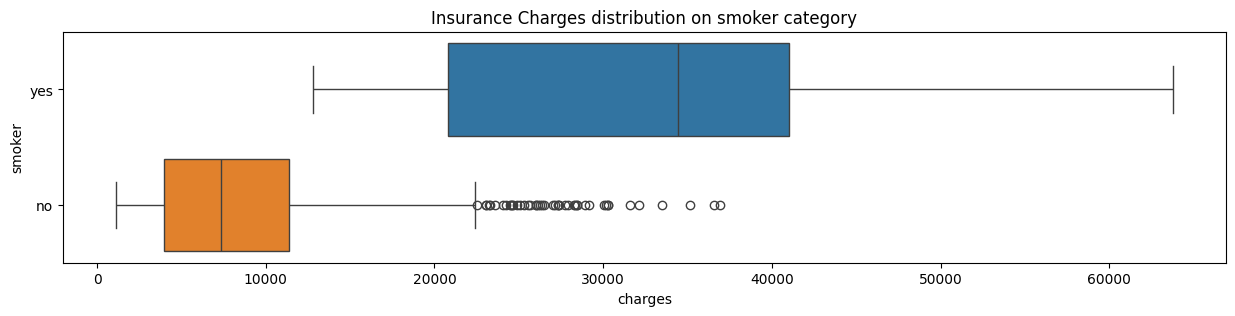

In [22]:
plt.figure(figsize = (15, 3))
plt.title("Insurance Charges distribution on smoker category")
sns.boxplot(data=df, x = 'charges', y = 'smoker', hue = 'smoker')

plt.show()

In [23]:
df2['encoded_smokers']= df['smoker'].apply(lambda X : 1 if X == 'yes' else 0 )

<Axes: >

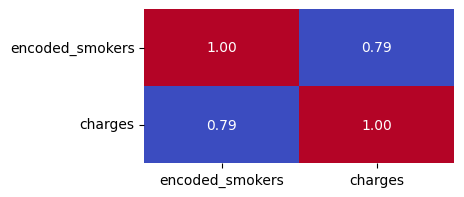

In [24]:
plt.figure(figsize = (4, 2))
sns.heatmap(data = df2[['encoded_smokers', 'charges']].corr(), annot = True, cbar = False, fmt = '0.2f', cmap = 'coolwarm')

- Here we can see, those who are smoker's insurance charges are higher.
- Those who are non smoker, insurance charges are lower as comapir to smoker's but outliers are present in non-smoker customers, might be high cost insurance, high charges on insurance.
- 75% of the non-smokers are paying insurance charges around 11500. minimum charge of smoker customers insurance charges start around 12000.
- both side data has highly skewed towards right side.
- Smoker category is highly correlated with charges.  

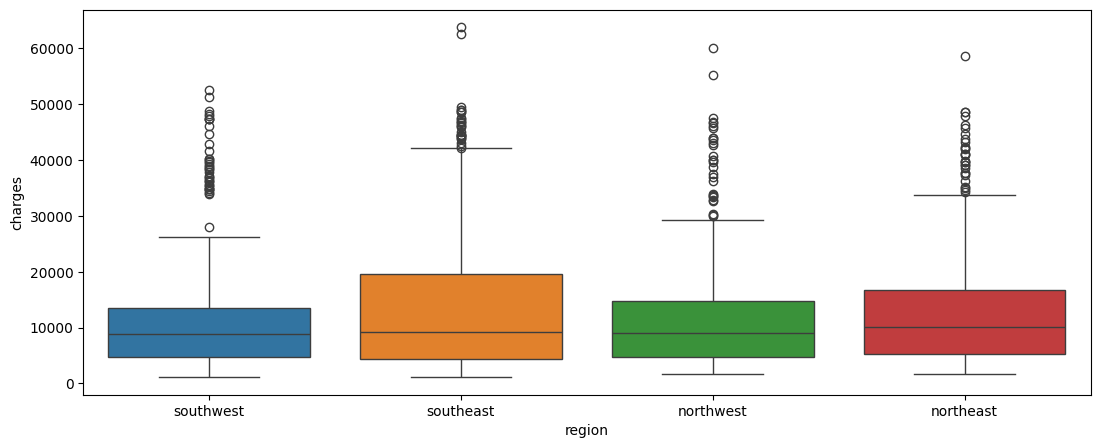

In [25]:
plt.figure(figsize = (13, 5))
sns.boxplot(data=df2, x = 'region', y = 'charges', hue = 'region')
plt.show()

In [26]:
df2['encode region'] = df['region'].apply(lambda x : 1 if x == 'southwest' else 2 if x == 'southeast' else 3 if x == 'nortwest' else 4)

<Axes: >

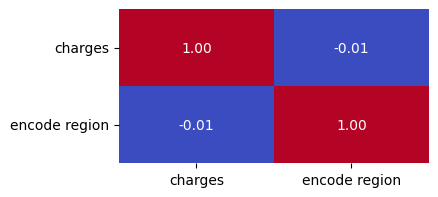

In [27]:
plt.figure(figsize = (4, 2))
sns.heatmap(data = df2[['charges', 'encode region']].corr(), annot = True, cbar = False, fmt = '0.2f', cmap = 'coolwarm')

- Region is not that much correlated with the charges.
- on an average <= 90000 charges are paying from all the preset region's.

# **_________________________________________________________________________________________________**

## **Data Prepration for Modelling**

In [28]:
X = df2.drop(['charges', 'encoded_smokers', 'encode region', 'encoded_sex'], axis=1)
y = df2['charges']

In [29]:
# Spliting the data for train & test on basis of 80:20 consideration.
# 80% data will go for train & 20% data will go for test.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42
)

In [30]:
print(f"total rows for train : {X_train.shape[0]}")

total rows for train : 1070


## **Model performance on independent veriable**

### **Charge Vs. age**

In [31]:
# defining model for train the data
model1 = LinearRegression()

In [32]:
independent_variable_1 = ['age']

In [33]:
model1.fit(X_train[independent_variable_1], y_train)

LinearRegression()

In [34]:
y_pred_train = model1.predict(X_train[independent_variable_1])

In [35]:
# Slop & Coefficient
print(f"Slop (m) : {model1.coef_.round(2)} \nintercept (b) : {model1.intercept_.round(2)}")

Slop (m) : [240.6] 
intercept (b) : 3876.93


In [82]:
# formula

print(f"Charges (Y) = {model1.coef_.round(2)} * {independent_variable_1} + {model1.intercept_.round(2)}")

Charges (Y) = [240.6] * ['age'] + 3876.93


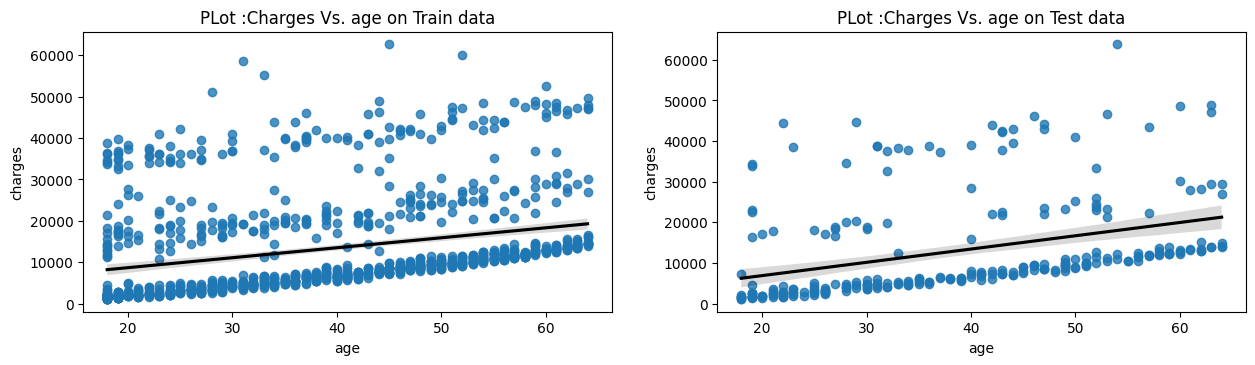

In [36]:
# Ploting a slop line on graph
plt.figure(figsize = (15, 8))

plt.subplot(2, 2, 1)
plt.title("PLot :Charges Vs. age on Train data")
sns.regplot(x = X_train[independent_variable_1], y = y_train, line_kws = {'color': 'black'})

plt.subplot(2, 2, 2)
plt.title("PLot :Charges Vs. age on Test data")
sns.regplot(x = X_test[independent_variable_1], y = y_test, line_kws = {'color': 'black'})
plt.show()

**Positive trend with moderate strength, highly outliers are present so varinace are increases**

## **Charges Vs. Sex**

**so, here we are using label encoder to transform 'sex' categorical column into numerical column.**

In [37]:
X['temp_sex_label_encode'] = X['sex'].apply(lambda b : 1 if b == 'male' else 0)

In [38]:
independent_variable_2 = ['temp_sex_label_encode']

In [74]:
# Checking the charges for male

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42
)

In [75]:
# defining the model & fitting data for training
model2 = LinearRegression()
model2.fit(X_train[independent_variable_2], y_train)

LinearRegression()

In [76]:
y_pred_train = model2.predict(X_train[independent_variable_2])

In [77]:
# checking slop (m) & intercept (b)

print(f"Slop (m) : {model2.coef_.round(2)} \nIntercept (b) : {model2.intercept_.round(2)}")

Slop (m) : [1365.24] 
Intercept (b) : 12646.88


In [78]:
# formula

print(f"Charges (Y) = ( {model2.coef_.round(2)} * {independent_variable_2} ) + {model2.intercept_.round(2)}")


Charges (Y) = ( [1365.24] * ['temp_sex_label_encode'] ) + 12646.88


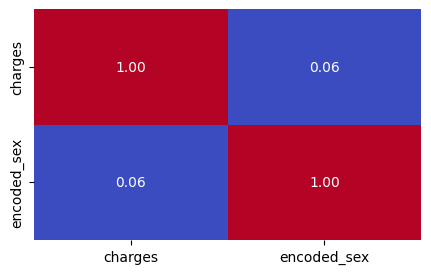

In [80]:
plt.figure(figsize = (5,3))
sns.heatmap(data = df2[['charges', 'encoded_sex']].corr(), annot = True, cbar = False, fmt= '0.2f', cmap = 'coolwarm')
plt.show()

- Not only alone Sex (independen variable) variable influencing Charges (dependent Variable)

## **Charges Vs. bmi**

In [84]:
# defining the independent variable
independent_variable_3 = ['bmi']

In [85]:
# defining the model & fitting data for training into the model
model3 = LinearRegression()
model3.fit(X_train[independent_variable_3], y_train)

LinearRegression()

In [86]:
# predicting the data on trained data
y_pred_train = model3.predict(X_train[independent_variable_3])

In [87]:
# checking the slop & intercept
print(f"Slop (m) : {model3.coef_.round(2)} \nIntercept (b) : {model3.intercept_.round(2)}")

Slop (m) : [392.44] 
Intercept (b) : 1353.07


In [88]:
print(f"Charges (Y) = {model3.coef_.round(2)} * {independent_variable_3} + {model3.intercept_.round(2)}")

Charges (Y) = [392.44] * ['bmi'] + 1353.07


**here, bmi increase by 1 charges will increase by 392.44 time**

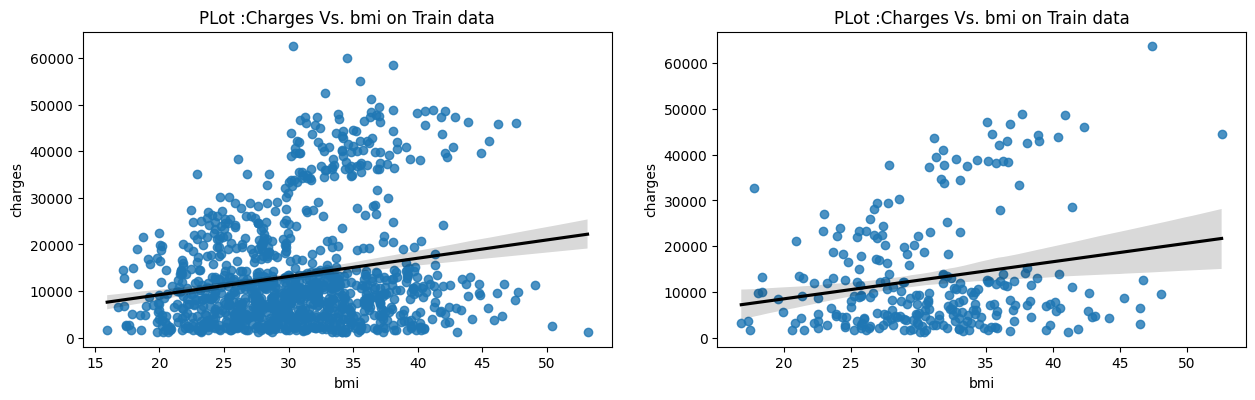

In [89]:
# ploting the slop on graph
plt.figure(figsize = (15, 9))

plt.subplot(2,2,1)
plt.title('PLot :Charges Vs. bmi on Train data')
sns.regplot(x = X_train[independent_variable_3], y = y_train, line_kws = {'color' : 'black'})

plt.subplot(2,2,2)
plt.title('PLot :Charges Vs. bmi on Train data')
sns.regplot(x = X_test[independent_variable_3], y = y_test, line_kws = {'color' : 'black'})
plt.show()

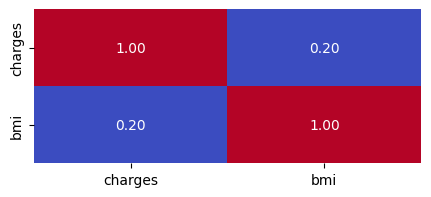

In [90]:
plt.figure(figsize = (5, 2))
sns.heatmap(data = df2[['charges', 'bmi']].corr(), annot = True, cbar = False, fmt = '0.2f', cmap = 'coolwarm')
plt.show()

- bmi has postive correlated with charges. but data points are widly spreded, so single bmi variable not influencing to insureance charges.
- but if we consider this variable with another independent varibales it will influence the insureance charges.
- Outliers are present.

## **Charges Vs. children**

In [91]:
# defining the independent varibale
independent_variable_4 = ['children']

In [92]:
# defining the model & fitting the data for training
model4 = LinearRegression()
model4.fit(X_train[independent_variable_4], y_train)

LinearRegression()

In [93]:
y_pred_train = model4.predict(X_train[independent_variable_4])

In [94]:
# checking the slop (m) & intercept (b)
print(f"Slop (m) : {model4.coef_.round(2)} \nIntercept (b) : {model4.intercept_.round(2)}")

Slop (m) : [710.55] 
Intercept (b) : 12559.17


In [95]:
# formula
print(f"Charges (Y): {model4.coef_.round(2)} * {independent_variable_4} + {model4.intercept_.round(2)}")

Charges (Y): [710.55] * ['children'] + 12559.17


**For every +1 increase in children, charges increase by 710.55**

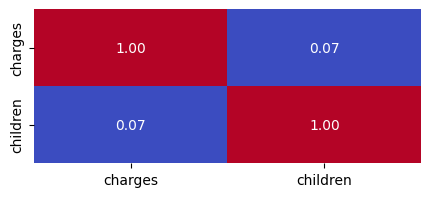

In [96]:
plt.figure(figsize = (5,2))
sns.heatmap(data=df2[['charges', 'children']].corr(), cbar = False, annot = True, fmt= '0.2f', cmap = 'coolwarm')
plt.show()

here, alone children varibale not that much influence to insureance.

## **charges Vs. smoker**

In [102]:
# lebel encoding for smoker column
X['label ecode smoker'] = X['smoker'].apply(lambda t : 1 if t == 'yes' else 0)

In [99]:
# defining the independent variable
independent_variable_5 = ['label ecode smoker']

In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42
)

In [106]:
# defining model
model5 = LinearRegression()
model5.fit(X_train[independent_variable_5], y_train)

LinearRegression()

In [107]:
y_pred_train = model5.predict(X_train[independent_variable_5])

In [108]:
# checking slop(m) & intercept(b)

print(f"Slop (m) : {model5.coef_.round(5)} \nIntercept (b) : {model5.intercept_.round(2)}")

Slop (m) : [23188.68587] 
Intercept (b) : 8578.32


In [109]:
# formula
print(f"charges (Y) = {model5.coef_.round(2)} * {independent_variable_5} + {model5.intercept_.round(2)}")

charges (Y) = [23188.69] * ['label ecode smoker'] + 8578.32


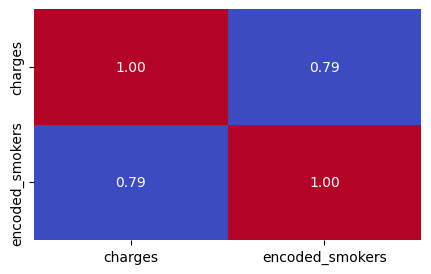

In [111]:
plt.figure(figsize = (5,3))
sns.heatmap(data = df2[['charges', 'encoded_smokers']].corr(), annot = True, cbar = False, fmt = '0.2f', cmap = 'coolwarm')
plt.show()

- Smoker & charges has high postive correlation.
- 1 smkoer can influence insureance charges 23188.9 time.

# **Charges Vs. All independent variables**

**to convert the all categorical varible into numerical we used OneHotEncoding process**

In [114]:
# previously we was crated a column so now we droped that column.
X.drop(['temp_sex_label_encode', 'label ecode smoker'], axis=1)

,age,sex,bmi,children,smoker,region
0,19,female,27.90,0,yes,southwest
1,18,male,33.77,1,no,southeast
2,28,male,33.00,3,no,southeast
3,33,male,22.70,0,no,northwest
4,32,male,28.88,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.97,3,no,northwest
1334,18,female,31.92,0,no,northeast
1335,18,female,36.85,0,no,southeast
1336,21,female,25.80,0,no,southwest


In [115]:
# used oneHotEncoding for transformation of categorical data into numercial data
X_ = pd.get_dummies(
    X,
    columns = X.select_dtypes(include = ['object', 'category']).columns.tolist(),
    drop_first = True
).astype(float)

In [116]:
# Spliting the data for train & test on ratio 80:20

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_,
    y,
    test_size = 0.20,
    random_state = 42
)

In [118]:
# defining a model

model6 = LinearRegression()

In [119]:
# fit the training data into model
model6.fit(X_train_1, y_train_1)

LinearRegression()

In [120]:
# Checking slop (m) & intercept (b)
print(f"Slop (m) : {model6.coef_.round(2)} \nIntercept (b) : {model6.intercept_.round(2)}")

Slop (m) : [ 2.569800e+02  3.370900e+02  4.252800e+02 -9.300000e+00  1.182556e+04
 -9.300000e+00  1.182556e+04 -3.706800e+02 -6.578600e+02 -8.098000e+02] 
Intercept (b) : -11931.22


In [123]:
# formula

euation = f"Charges (Y) "

# **Model Performance Evalution**

analysis of customer attributes like age, sex, smoking habits, etc. can be crucial in making decisions regarding the premium amount to be charged.

In [281]:
X.head()

,age,sex,bmi,children,smoker,region,temp_sex_label_encode
0,19,female,27.90,0,yes,southwest,0
1,18,male,33.77,1,no,southeast,1
2,28,male,33.00,3,no,southeast,1
3,33,male,22.70,0,no,northwest,1
4,32,male,28.88,0,no,northwest,1


In [232]:
df2.head()

,age,sex,bmi,children,smoker,region,charges,encoded_smokers,encode region
0,19,female,27.90,0,yes,southwest,16884.92,1,1
1,18,male,33.77,1,no,southeast,1725.55,0,2
2,28,male,33.00,3,no,southeast,4449.46,0,2
3,33,male,22.70,0,no,northwest,21984.47,0,4
4,32,male,28.88,0,no,northwest,3866.86,0,4
